# Functions

Let's import the necessary libraries.

In [1]:
import brainstate as bst
import numpy as np

import pinnx

Define the geometry of the problem domain.

In [2]:
geom = pinnx.geometry.Interval(-1, 1)

Set the number of training and testing samples.

In [3]:
num_train = 16
num_test = 100

Define the function to be approximated.

In [4]:
def func(x):
    """
    x: array_like, N x D_in
    y: array_like, N x D_out
    """
    return x * np.sin(5 * x)

Generate the training and testing data using the defined function and geometry.

In [5]:
data = pinnx.data.Function(geom, func, num_train, num_test)

Initialize the neural network with the specified architecture and activation function.

In [6]:
net = pinnx.nn.FNN([1] + [20] * 3 + [1], "tanh", bst.init.LecunUniform())

Create a model using the generated data and the neural network.

In [7]:
model = pinnx.Model(data, net)

Compile the model with an optimizer and metrics for evaluation.

In [8]:
model.compile(bst.optim.Adam(0.001), metrics=["l2 relative error"])

Compiling model...
'compile' took 0.038041 s



Train the model for a specified number of iterations.

In [10]:
losshistory, train_state = model.train(iterations=30000)

Training model...

Step      Train loss    Test loss     Test metric   
0         [4.16e-01]    [3.72e-01]    [1.34e+00]    
1000      [1.97e-03]    [1.55e-03]    [8.61e-02]    
2000      [1.25e-03]    [1.00e-03]    [6.93e-02]    
3000      [8.73e-04]    [7.36e-04]    [5.94e-02]    
4000      [5.19e-04]    [4.44e-04]    [4.61e-02]    
5000      [1.72e-04]    [1.77e-04]    [2.91e-02]    
6000      [5.48e-05]    [8.93e-05]    [2.07e-02]    
7000      [1.34e-05]    [5.65e-05]    [1.64e-02]    
8000      [1.79e-06]    [4.75e-05]    [1.51e-02]    
9000      [5.64e-07]    [4.46e-05]    [1.46e-02]    
10000     [1.62e-06]    [4.42e-05]    [1.45e-02]    
11000     [1.06e-07]    [4.10e-05]    [1.40e-02]    
12000     [5.13e-08]    [4.00e-05]    [1.38e-02]    
13000     [2.55e-08]    [3.94e-05]    [1.37e-02]    
14000     [1.94e-08]    [3.90e-05]    [1.37e-02]    
15000     [3.61e-06]    [4.42e-05]    [1.45e-02]    
16000     [1.19e-07]    [3.90e-05]    [1.37e-02]    
17000     [2.55e-07]    [3.

Save and plot the training history and state.

Saving loss history to c:\Github\pinnx\docs\function\loss.dat ...
Saving training data to c:\Github\pinnx\docs\function\train.dat ...
Saving test data to c:\Github\pinnx\docs\function\test.dat ...


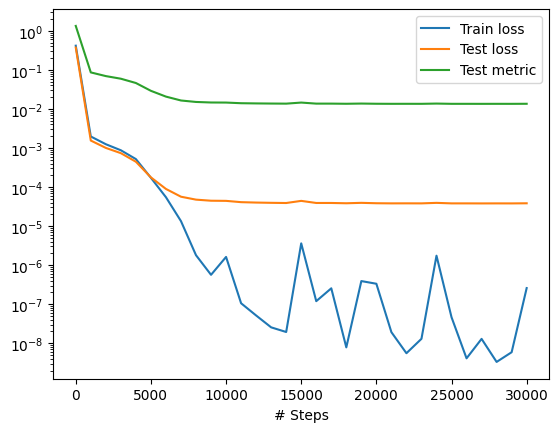

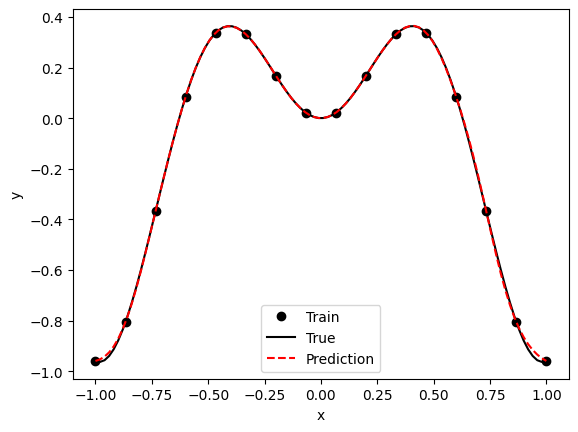

In [11]:
pinnx.saveplot(losshistory, train_state, issave=True, isplot=True)